# Homework 5

In [17]:
import os
from glob import glob

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [18]:
from tasks import *

# Задача №1 - Можете ли вы отличить сорняки от рассады?

Теперь приступим к задаче классификации на картинках. Реализуйте программу, которая определяет тип рассады на изображении. 

Для того, чтобы определить характерные особенности каждого типа рассады, у вас есть train. Train это папка, в которой картинки уже классифицированы и лежат в соответствующих папках. Исходя из этой информации можете найти признаки, присущие конкретному растению.

Проверка вашего решения будет на происходить на test. В папке test уже нет метки класса для каждой картинки. 

[Ссылка на Яндекс-диск](https://yadi.sk/d/0Zzp0klXT0iRmA), все картинки тут.

Примеры изображений для теста:
<table><tr>
    <td> <img src="https://i.ibb.co/tbqR37m/fhj.png" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="https://i.ibb.co/6yL3Wmt/sfg.png" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="https://i.ibb.co/pvn7NvF/asd.png" alt="Drawing" style="width: 200px;"/> </td>
</tr></table>

In [19]:
train_dir = os.path.join("plants", "train")
test_dir = os.path.join("plants", "test")

feature_size = 100
random_state = 42

# Ground truth labels
y_test = np.array([0, 0, 1, 1, 0, 0, 2, 3, 1, 0, 1, 1, 0, 3, 2, 3, 2, 3, 0, 3,
                   2, 2, 3, 1, 3, 2, 2, 1, 3, 3, 0, 2, 0, 0, 1, 2, 3, 2, 1, 1])

In [20]:
class_names = sorted(os.listdir(train_dir))
image_paths = []
labels = []

for label, class_name in enumerate(class_names):
  class_path = os.path.join(train_dir, class_name)

  for img_path in glob(os.path.join(class_path, "*.png")):
    image_paths.append(img_path)
    labels.append(label)

k_means = TrainKMeans(image_paths, feature_size, random_state)

x_train = []
for path in image_paths:
  feature_vector = PredictAndArrayTransform(path, k_means, feature_size)
  x_train.append(feature_vector)

x_train = np.array(x_train)
y_train = np.array(labels)

classifier = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=random_state))
])

classifier.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression(random_state=42))])

In [21]:
test_image_paths = glob(os.path.join(test_dir, "*.png"))
y_pred = []

for img_path in test_image_paths:
  feature_vector = PredictAndArrayTransform(img_path, k_means, feature_size)
  probabilities = classifier.predict_proba([feature_vector])[0]

  top_class_idx = np.argmax(probabilities)
  top_class_name = class_names[top_class_idx]
  top_confidence = probabilities[top_class_idx]

  y_pred.append(top_class_idx)

In [22]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")

Accuracy: 1.00000


# Задача №2 - Собери пазл (2.0).

Даны кусочки изображения, ваша задача склеить пазл в исходную картинку. 

Условия:
* Дано исходное изображение для проверки, использовать собранное изображение в самом алгоритме нельзя;
* Картинки имеют друг с другом пересечение;
* После разрезки кусочки пазлов не были повернуты или отражены;
* НЕЛЬЗЯ выбрать опорную картинку для сбора пазла, как это было в homework 3
* В процессе проверки решения пазлы могут быть перемешаны, т.е. порядок пазлов в проверке может отличаться от исходного 

Изображения расположены по [ссылке](https://disk.yandex.ru/d/XtpawH1sV9UDlg).

Примеры изображений:
<img src="puzzle/su_fighter.jpg" alt="Drawing" style="width: 300px;"/>
<table><tr>
    <td> <img src="puzzle/su_fighter_shuffle/0.jpg" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="puzzle/su_fighter_shuffle/1.jpg" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="puzzle/su_fighter_shuffle/2.jpg" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="puzzle/su_fighter_shuffle/3.jpg" alt="Drawing" style="width: 200px;"/> </td>
</tr></table>

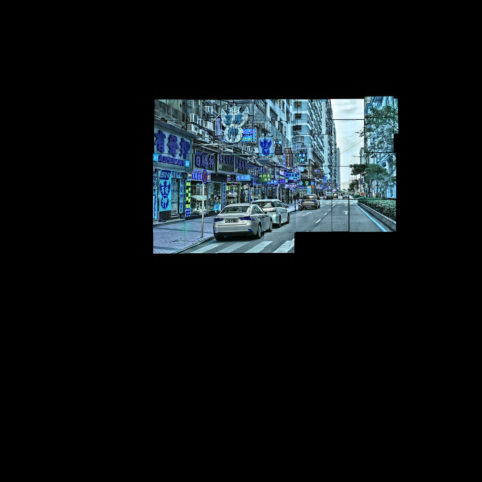

In [28]:
images_paths = glob(f"{os.getcwd()}/puzzle/china_shuffle/*")

Puzzle(images_paths)

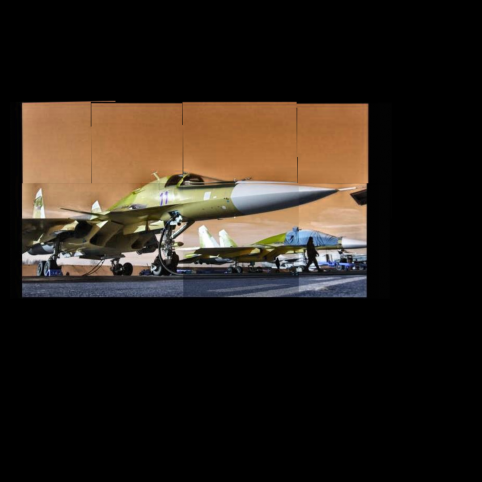

In [29]:
images_paths = glob(f"{os.getcwd()}/puzzle/su_fighter_shuffle/*")

Puzzle(images_paths)